#General Questions to Answer:

1. What is our experimental value of G_0? How does G_0 compare to actual G_0?
2. Does it depend on V_in?
3. What are sources of noise and error?

#Regular Voltage and Conductance Graphs

"\n  # Plot histogram of conductance counts for the frame\n  plt.figure(figsize = (12,6))\n  plt.hist(G, bins = n_bins,color='red', edgecolor='black')\n  plt.xlabel('Conductance (G) [S]')\n  plt.ylabel('Count')\n  plt.title(f'Conductance for {i}00mV Input Voltage')\n"

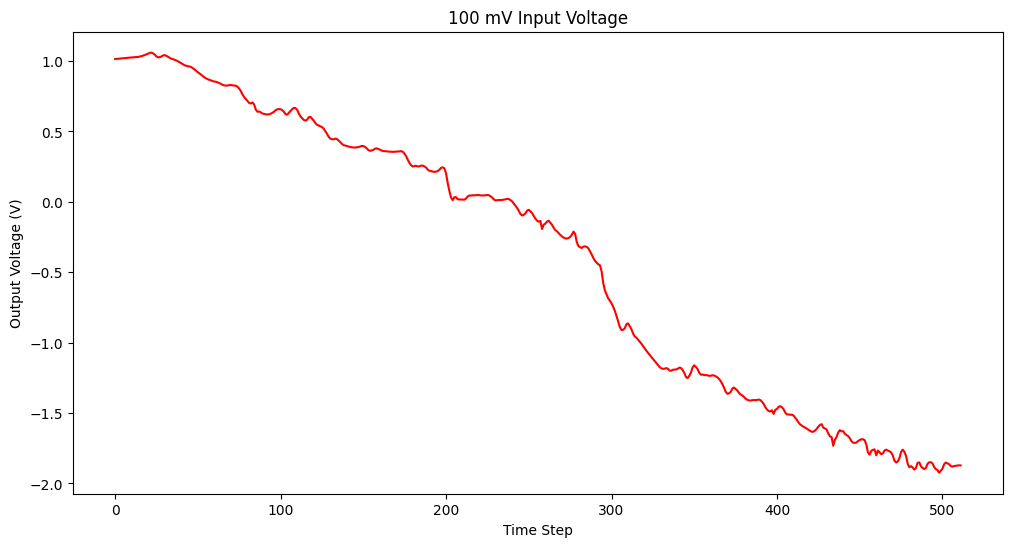

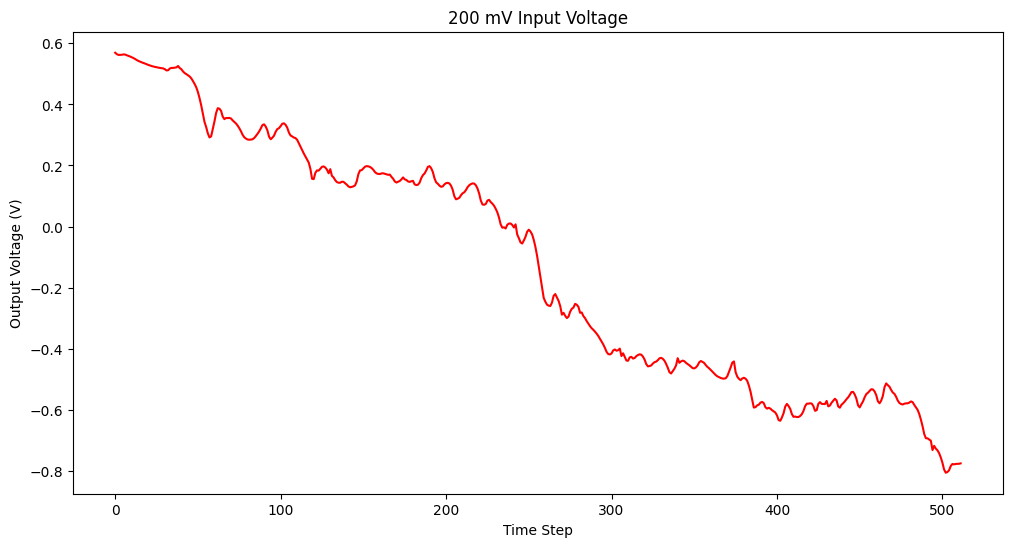

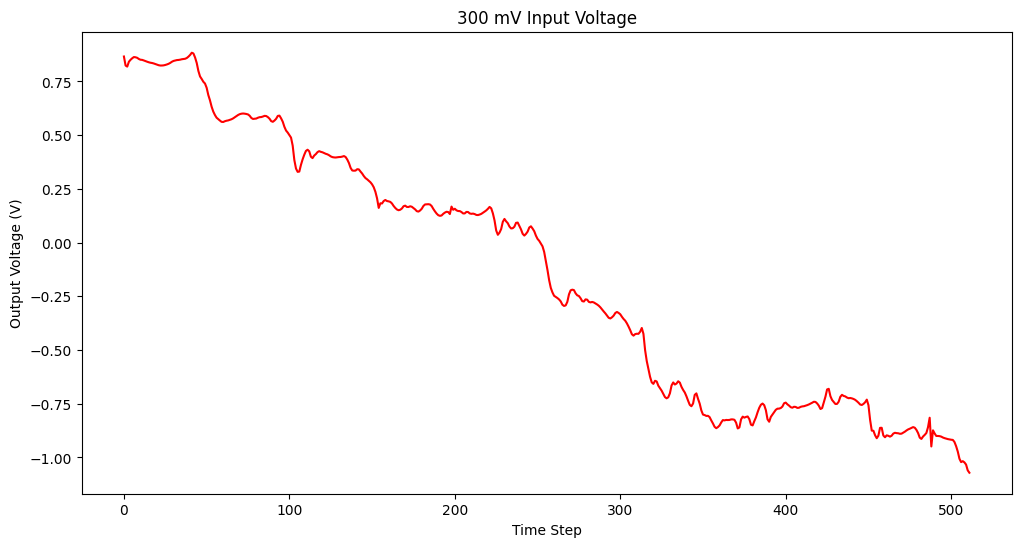

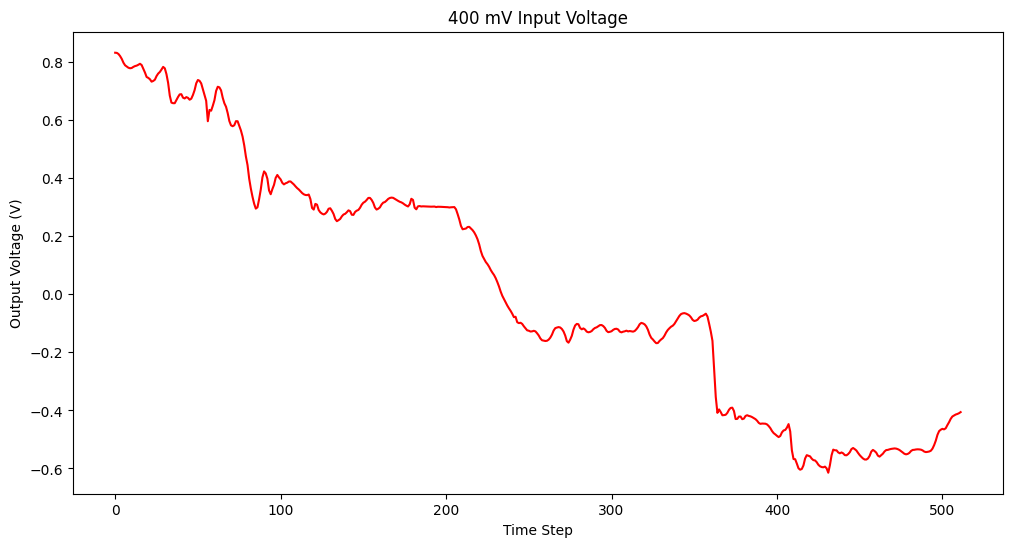

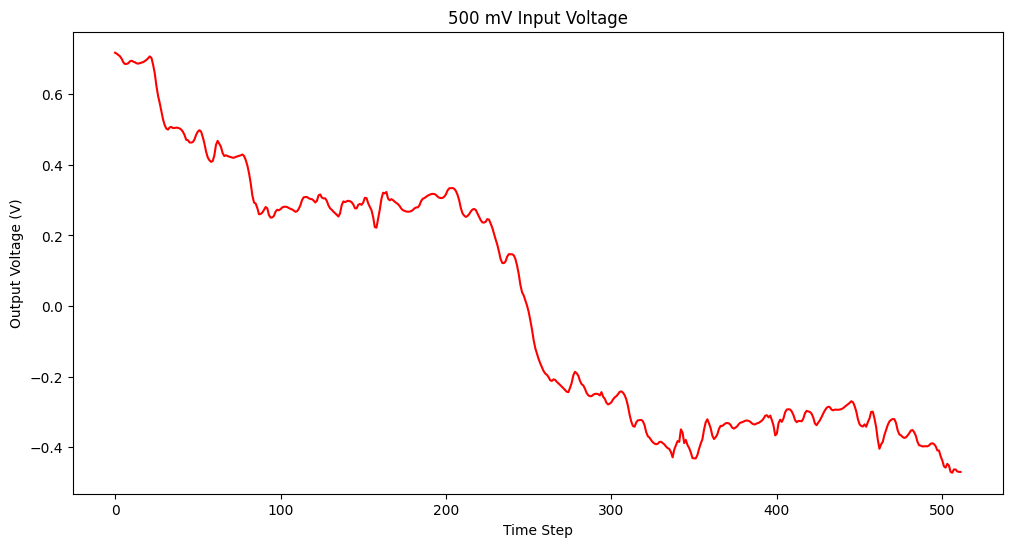

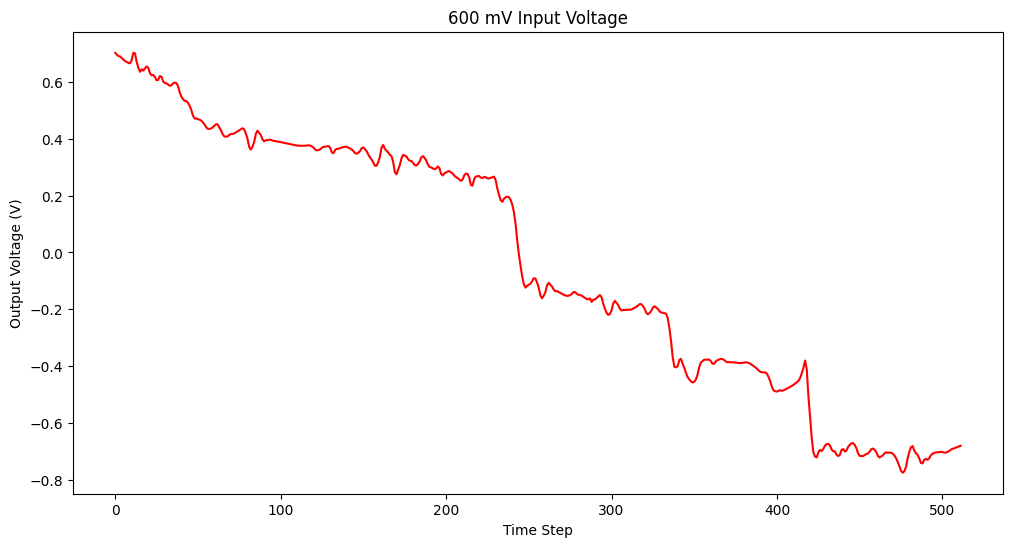

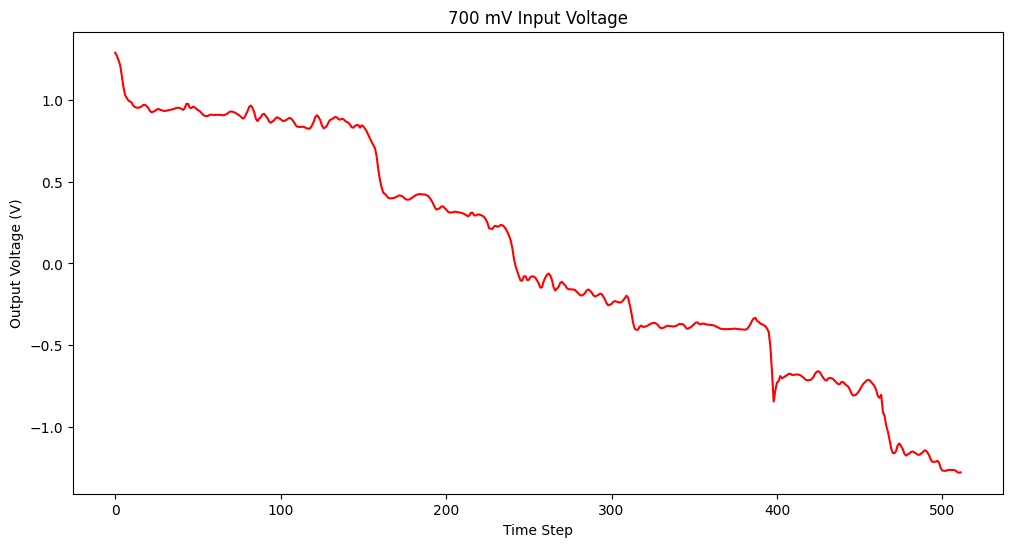

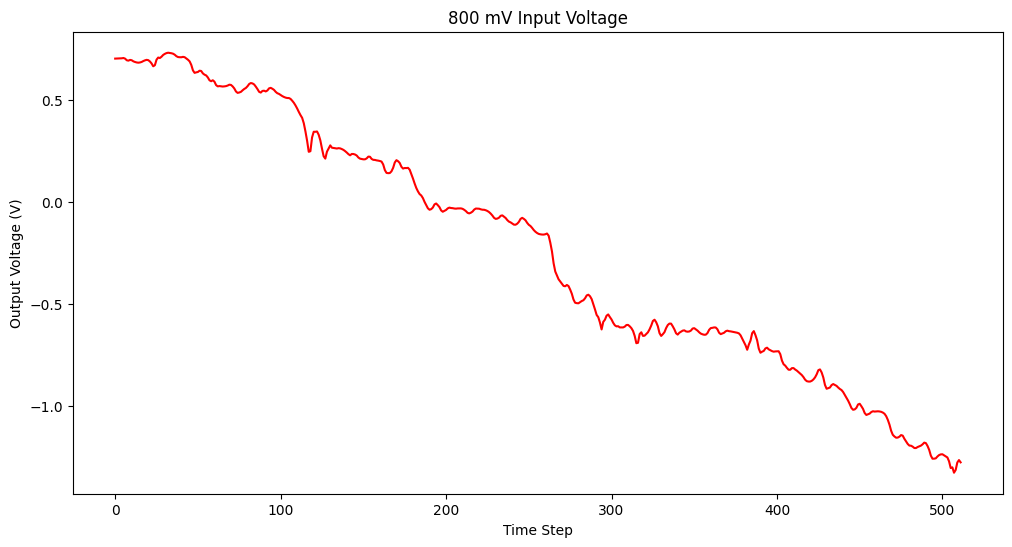

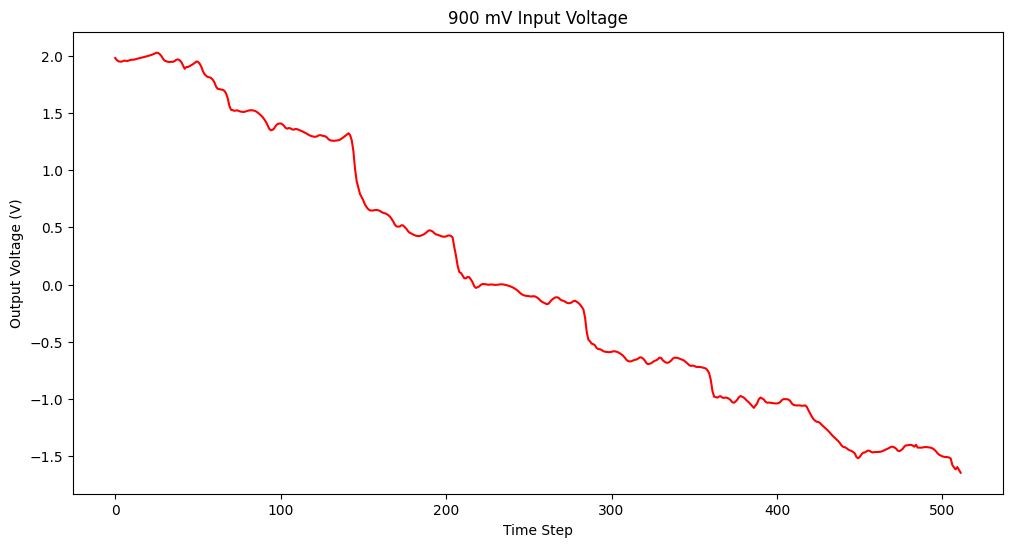

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pywt

r_in = 100_000 # Input resistance in Ohms
e = 1.602e-19
h = 6.626e-34
G_0 = (2 * e**2) / h

rows = [3172,408,2048,3056,1900,1068,784,2216,1848]

def denoising_function(data, wavelet='db4',level=2):
  coeffs = pywt.wavedec(data, wavelet)
  threshold = np.std(coeffs[-level])
  coeffs = [pywt.threshold(c, threshold) for c in coeffs]
  denoised_data = pywt.waverec(coeffs, wavelet)
  return denoised_data


for i in range(1,10):

  # Read the data file in
  df = pd.read_csv(f'{i}00mV.csv',header=None)

  v_in = i / 10 # Input voltage in Volts

  row = df.iloc[rows[i-1]] # Isolate the row
  v_out = row.to_numpy(dtype=float).ravel() # Converts all the values into one long array

  ##### DENOISE DATA #####
  denoised_v = denoising_function(v_out)



  G = - (denoised_v/(r_in * v_in)) # Calculate G (Conductance)

  n_bins = int(np.sqrt(len(denoised_v)))

  # Plot voltage as a function of time for the frame
  plt.figure(figsize = (12,6))
  plt.plot(denoised_v, color='red')
  plt.xlabel('Time Step')
  plt.ylabel('Output Voltage (V)')
  plt.title(f'{i}00 mV Input Voltage')

'''
  # Plot histogram of conductance counts for the frame
  plt.figure(figsize = (12,6))
  plt.hist(G, bins = n_bins,color='red', edgecolor='black')
  plt.xlabel('Conductance (G) [S]')
  plt.ylabel('Count')
  plt.title(f'Conductance for {i}00mV Input Voltage')
'''


"\n# Plot histogram of conductance counts for the frame\nplt.figure(figsize = (12,6))\nplt.hist(G, bins = n_bins,color='red', edgecolor='black')\nplt.xlabel('Conductance (G) [S]')\nplt.ylabel('Count')\nplt.title('Conductance for 1V Input Voltage')\n"

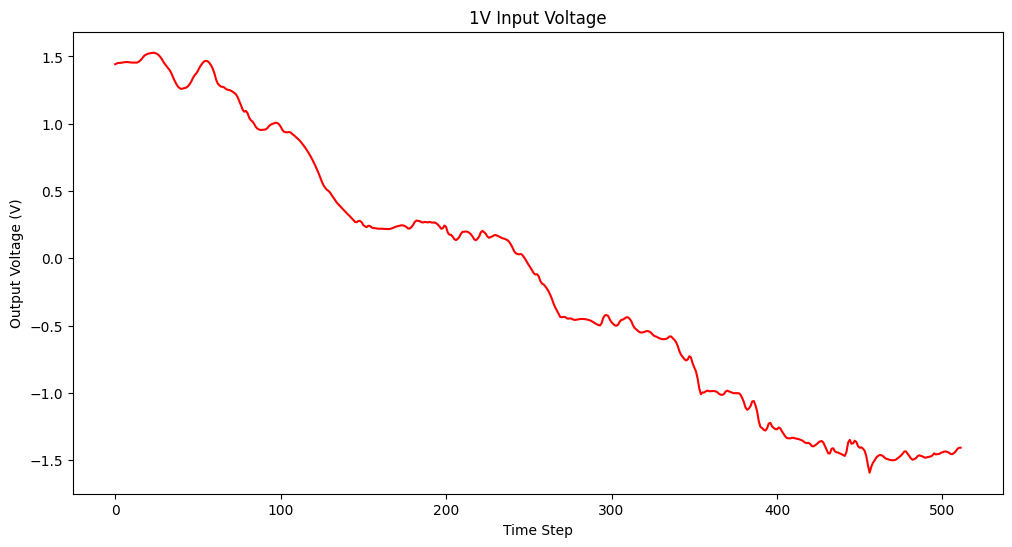

In [ ]:
r_in = 100_000 # Input resistance in Ohms
e = 1.602e-19
h = 6.626e-34
G_0 = (2 * e**2) / h

# Read the data file in
df = pd.read_csv('1V.csv',header=None)

v_in = 1 # Input voltage in Volts

row = df.iloc[1908] # Isolate the row
v_out = row.to_numpy(dtype=float).ravel() # Converts all the values into one long array

##### DENOISE DATA #####
denoised_v = denoising_function(v_out)

G = - (denoised_v/(r_in * v_in)) # Calculate G (Conductance)

n_bins = int(np.sqrt(len(denoised_v)))

# Plot voltage as a function of time for the frame
plt.figure(figsize = (12,6))
plt.plot(denoised_v, color='red')
plt.xlabel('Time Step')
plt.ylabel('Output Voltage (V)')
plt.title('1V Input Voltage')

'''
# Plot histogram of conductance counts for the frame
plt.figure(figsize = (12,6))
plt.hist(G, bins = n_bins,color='red', edgecolor='black')
plt.xlabel('Conductance (G) [S]')
plt.ylabel('Count')
plt.title('Conductance for 1V Input Voltage')
'''

# Aggregate Conductance Trace

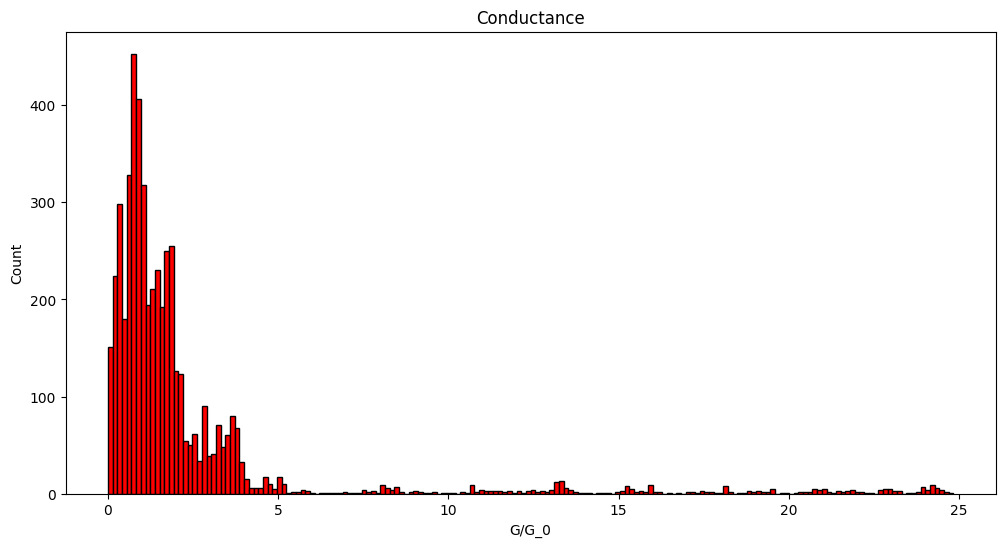

Peak: 0.6902034621754822


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

r_in = 100_000 # Input resistance in Ohms
e = 1.602e-19
h = 6.626e-34
G_0 = (2 * e**2) / h

rows = [3172,408,2048,3056,1900,1068,784,2216,1848]
ag_cond = np.array([])

# Iterate through the 100's files
for i in range(1,10):

  # Read the data file in
  df = pd.read_csv(f'{i}00mV.csv',header=None)

  v_in = i / 10 # Input voltage in Volts

  row = df.iloc[rows[i-1]] # Isolate the row
  v_out = row.to_numpy(dtype=float).ravel() # Converts all the values into one long array

  denoised_v = denoising_function(v_out)

  G = - (denoised_v/(r_in * v_in)) # Calculate G (Conductance)

  real_g = np.abs(G/G_0)

  ag_cond = np.append(ag_cond, real_g)

df = pd.read_csv('1V.csv',header=None)
v_in = 1
row = df.iloc[1908]
v_out = row.to_numpy(dtype=float).ravel()

denoised_v = denoising_function(v_out)

G = - (denoised_v/(r_in * v_in)) # Calculate G (Conductance)

real_g = np.abs(G/G_0)
ag_cond = np.append(ag_cond, real_g)

### Multiplied by ten to match the actual quantum conductance paper
ag_cond = ag_cond *10

n_bins = int(np.sqrt(len(ag_cond)))


# Plot histogram of conductance counts for the frame
plt.figure(figsize = (12,6))
n, bins, patches = plt.hist(ag_cond, bins = 180,color='red', edgecolor='black')
plt.xlabel('G/G_0')
plt.ylabel('Count')
plt.title('Conductance')
plt.show()

index = np.argmax(n)
highest_x = bins[index]
print("Peak:", highest_x)